In [90]:

import numpy as np
import pandas as pd


In [91]:
from google.colab import files
upload= files.upload()

Saving QVI_data.csv to QVI_data (1).csv


In [92]:
df=pd.read_csv('QVI_data.csv')

In [93]:
df.head(5)

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [95]:
df.isnull().sum()

,0
LYLTY_CARD_NBR,0
DATE,0
STORE_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
PACK_SIZE,0
BRAND,0


In [96]:
df['DATE']=pd.to_datetime(df['DATE'])


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   LYLTY_CARD_NBR    264834 non-null  int64         
 1   DATE              264834 non-null  datetime64[ns]
 2   STORE_NBR         264834 non-null  int64         
 3   TXN_ID            264834 non-null  int64         
 4   PROD_NBR          264834 non-null  int64         
 5   PROD_NAME         264834 non-null  object        
 6   PROD_QTY          264834 non-null  int64         
 7   TOT_SALES         264834 non-null  float64       
 8   PACK_SIZE         264834 non-null  int64         
 9   BRAND             264834 non-null  object        
 10  LIFESTAGE         264834 non-null  object        
 11  PREMIUM_CUSTOMER  264834 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory usage: 24.2+ MB


In [98]:
df[['TOT_SALES','PACK_SIZE','PROD_QTY']].describe()

,TOT_SALES,PACK_SIZE,PROD_QTY
count,264834.000000,264834.000000,264834.000000
mean,7.299346,182.425512,1.905813
std,2.527241,64.325148,0.343436
min,1.500000,70.000000,1.000000
25%,5.400000,150.000000,2.000000
50%,7.400000,170.000000,2.000000
75%,9.200000,175.000000,2.000000
max,29.500000,380.000000,5.000000


In [99]:
df = df[df['PROD_NAME'].str.contains('chips', case=False, na=False)]

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

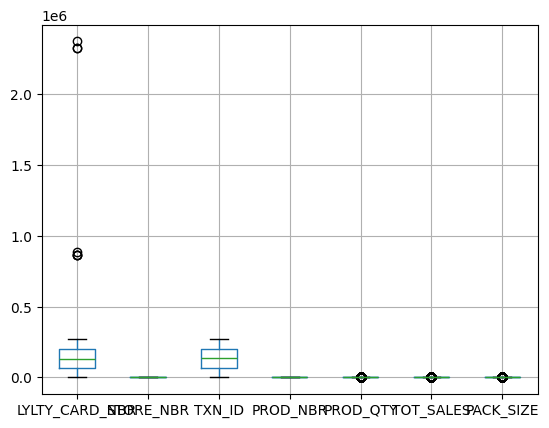

In [101]:
df.boxplot()

In [102]:
def replace_outliers_with_mean(df,column):
  q1= df[column].quantile(0.25)
  q3= df[column].quantile(0.75)
  IQR=q3-q1
  lower_bound=q1-1.5*IQR
  upper_bound=q3+1.5*IQR
  mean_value=df[column].mean()
  df[column] = df[column].apply(lambda x: mean_value if x < lower_bound or x > upper_bound else x)

  return df

In [103]:
columns= ['PROD_QTY','TOT_SALES','PACK_SIZE']

for col in columns:
  replace_outliers_with_mean(df,col)


<Axes: >

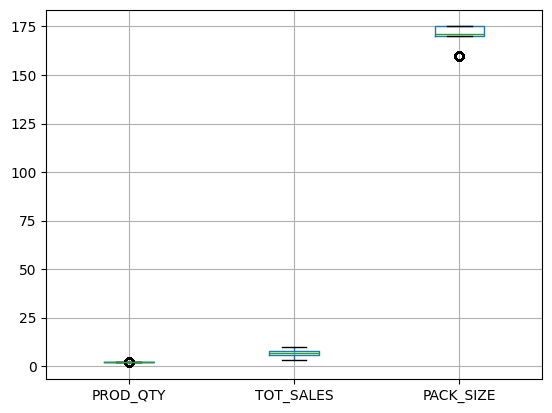

In [104]:
df[['PROD_QTY','TOT_SALES','PACK_SIZE']].boxplot()

In [105]:
df=df.sort_values(by='DATE')

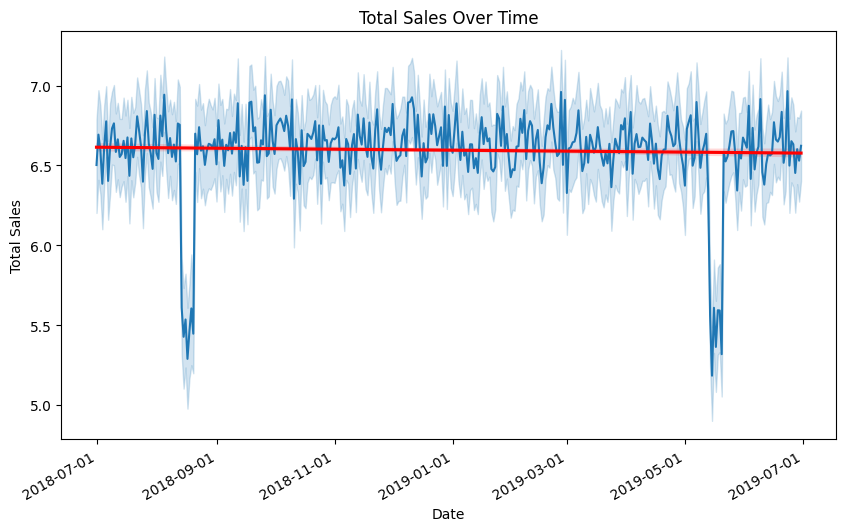

In [106]:
import matplotlib.dates as mdates

plt.figure(figsize=(10,6))
sns.lineplot(data=df,x='DATE',y='TOT_SALES')

df_for_regplot = df.copy()
df_for_regplot['DATE_NUM'] = mdates.date2num(df_for_regplot['DATE'])

sns.regplot(x='DATE_NUM', y='TOT_SALES', data=df_for_regplot, scatter=False, color='red')

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

In [107]:
top_10=pd.DataFrame(df.groupby(['PROD_NAME','PREMIUM_CUSTOMER'])['TOT_SALES'].sum().nlargest(10)).reset_index()

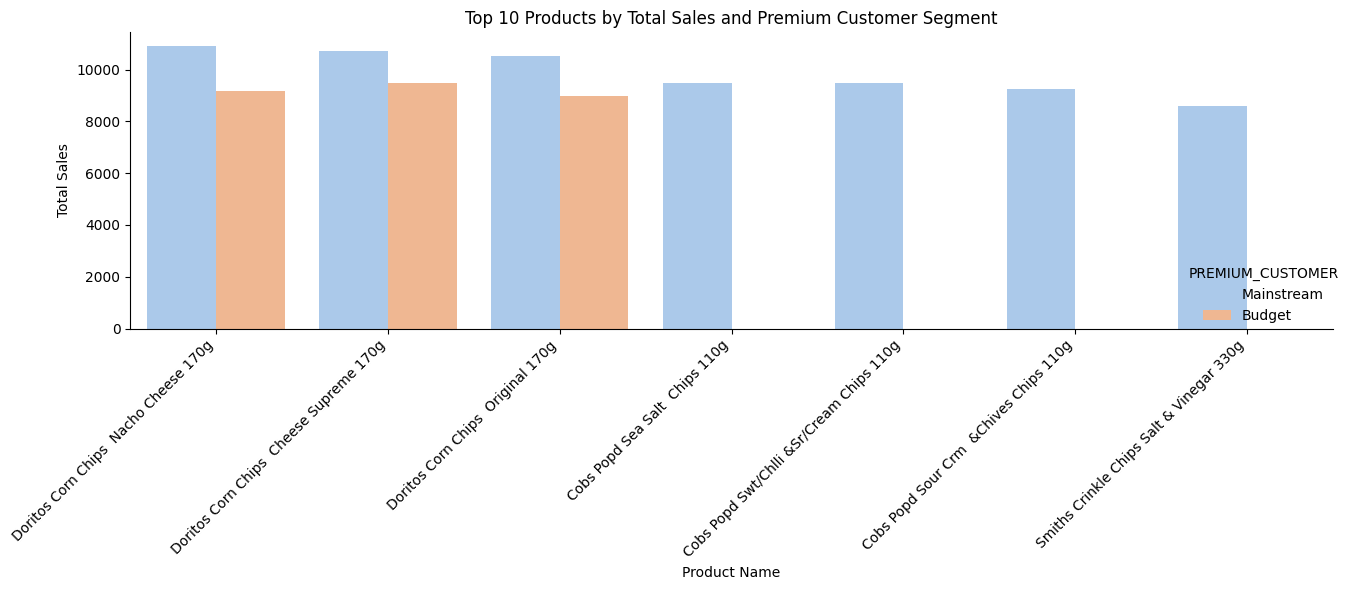

In [108]:
sns.catplot(data=top_10, x='PROD_NAME', y='TOT_SALES', kind='bar', hue='PREMIUM_CUSTOMER', height=6, aspect=2,palette='pastel')
plt.title('Top 10 Products by Total Sales and Premium Customer Segment')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_514/2675810776.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='BRAND',y='TOT_SALES',palette='Blues')


Text(0, 0.5, 'Total Sales')

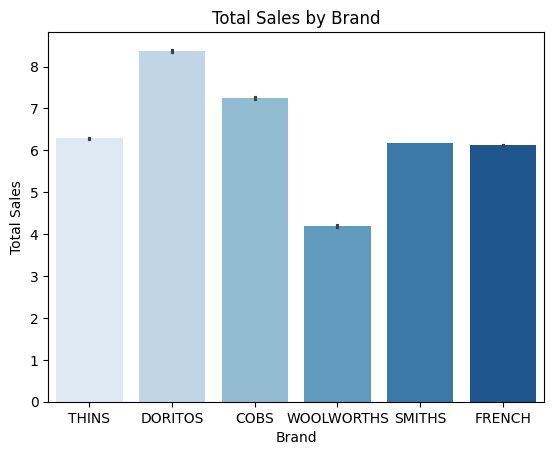

In [109]:
sns.barplot(data=df,x='BRAND',y='TOT_SALES',palette='Blues')
plt.title('Total Sales by Brand')
plt.xlabel('Brand')
plt.ylabel('Total Sales')

/tmp/ipykernel_514/2658582512.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='PACK_SIZE',y='TOT_SALES',palette='viridis')


([0, 1, 2, 3],
 [Text(0, 0, '160.0'),
  Text(1, 0, '170.0'),
  Text(2, 0, '171.36276873618647'),
  Text(3, 0, '175.0')])

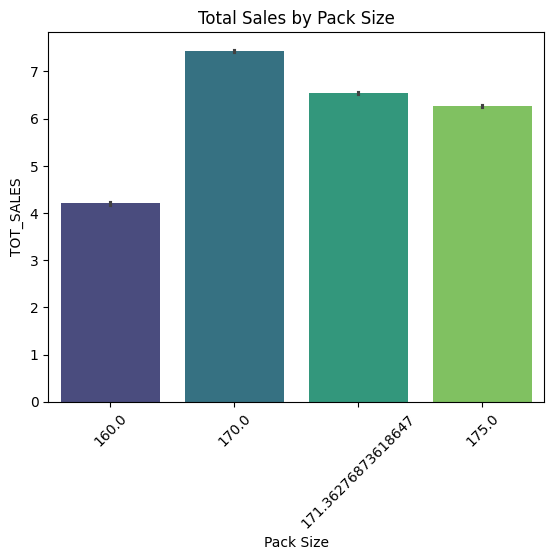

In [110]:
sns.barplot(data=df,x='PACK_SIZE',y='TOT_SALES',palette='viridis')
plt.title('Total Sales by Pack Size')
plt.xlabel('Pack Size')
plt.xticks(rotation=45)

In [111]:
df['month_year'] = df['DATE'].dt.strftime('%Y-%m')

In [112]:
df['STORE_NBR'].unique()

array([123,  17, 122,  23,  45, 229, 208, 128,  33,   1,  67,  29, 226,
       207, 241, 270, 165, 269,   7, 213,  26, 223,  58,  87, 194, 190,
       238, 191,  81, 260, 169, 236,  83,  39,  93,  56, 111, 262, 232,
       197,  60,  80, 196, 149, 153, 118,  68, 155, 108, 222, 230, 119,
       144,  88,  36, 254,  73,  63,  98,  95, 231, 217, 102,  19,  57,
        35, 182, 209, 110, 259, 263,  59, 168, 147,  24,  53,  91, 137,
       184, 221,  28, 109, 245,  75,  71, 233, 195,  97, 167, 174, 101,
        50, 166, 180,  49, 133, 200,  69,   3, 113,  43, 237,  13, 157,
        78, 239, 181,  99,  90, 105, 106,  94,  46,  86, 152, 141,  25,
        32, 266,   4, 242, 115,  48, 250, 172, 255, 100, 121, 154, 103,
       271, 104, 164, 203,  40, 114, 173,  27, 264, 243,  82, 219, 148,
       210, 171, 216, 127, 126,  96,   2,   5, 225, 130,  41, 156,  79,
        47,  10, 261, 199, 201, 235,  18, 183, 129, 160, 257,  64, 185,
        37, 187, 227, 205, 253, 248,  22, 228, 179, 247,  62, 13

In [113]:

filtered_df = df[df['STORE_NBR'].isin([77,86,88])]

In [114]:
monthly_metrics = filtered_df.groupby(['STORE_NBR','month_year']).agg(
    monthly_sales=('TOT_SALES','sum'),
    customers=('LYLTY_CARD_NBR','nunique'),
    transactions=('TXN_ID','nunique')
).reset_index()

In [115]:
monthly_metrics['txn_per_customer'] = (monthly_metrics['transactions'] / monthly_metrics['customers'])
monthly_metrics.tail()

,STORE_NBR,month_year,monthly_sales,customers,transactions,txn_per_customer
31,88,2019-02,248.700394,32,32,1.000000
32,88,2019-03,253.250591,35,35,1.000000
33,88,2019-04,216.900394,29,29,1.000000
34,88,2019-05,229.700788,30,31,1.033333
35,88,2019-06,202.350197,27,27,1.000000


In [116]:
filtered_df.groupby('LYLTY_CARD_NBR')['TXN_ID'].nunique().sort_values(ascending=False).head()

,TXN_ID
LYLTY_CARD_NBR,
88180,5
88105,5
86151,5
86059,5
86193,4


In [117]:
monthly_metrics.sort_values(by='transactions', ascending=False).head(10)

,STORE_NBR,month_year,monthly_sales,customers,transactions,txn_per_customer
24,88,2018-07,310.800788,41,42,1.024390
29,88,2018-12,269.000788,35,36,1.028571
32,88,2019-03,253.250591,35,35,1.000000
28,88,2018-11,243.050591,31,33,1.064516
31,88,2019-02,248.700394,32,32,1.000000
30,88,2019-01,227.900394,30,31,1.033333
34,88,2019-05,229.700788,30,31,1.033333
16,86,2018-11,196.700394,29,30,1.034483
25,88,2018-08,222.700394,30,30,1.000000
17,86,2018-12,179.150197,30,30,1.000000


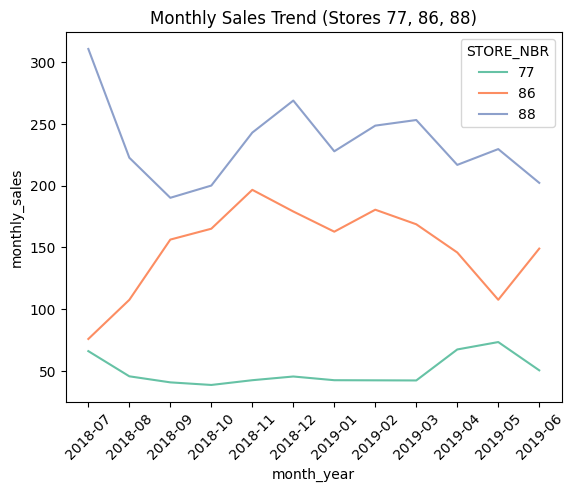

In [118]:
sns.lineplot(data=monthly_metrics, x='month_year', y='monthly_sales', hue='STORE_NBR', palette='Set2')
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend (Stores 77, 86, 88)")
plt.show()

In [119]:
monthly_metrics_df = df.groupby(['STORE_NBR','month_year']).agg(
    monthly_sales=('TOT_SALES','sum'),
    customers=('LYLTY_CARD_NBR','nunique'),
    transactions=('TXN_ID','nunique')
).reset_index()

In [120]:
sales = monthly_metrics_df.pivot(index='month_year',columns='STORE_NBR',values='monthly_sales')

In [121]:
trial_stores = [77,86,88]

for store in trial_stores:
    control_store = sales.corr()[store].drop(store).idxmax()
    print(f"Best control store for {store} is {control_store}")

Best control store for 77 is 115
Best control store for 86 is 246
Best control store for 88 is 263


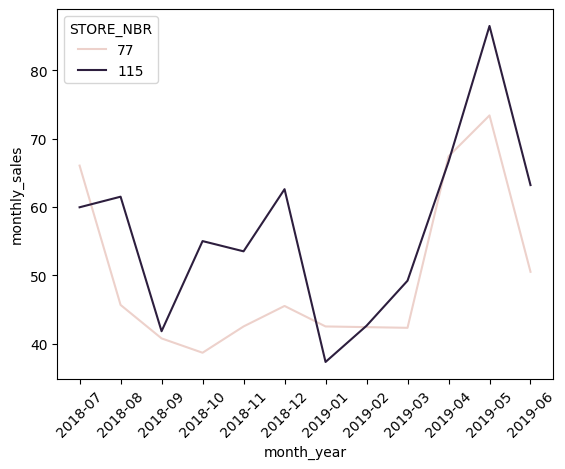

In [122]:
compare = monthly_metrics_df[monthly_metrics_df['STORE_NBR'].isin([77, 115])]

sns.lineplot(data=compare,
             x='month_year',
             y='monthly_sales',
             hue='STORE_NBR')
plt.xticks(rotation=45)
plt.show()

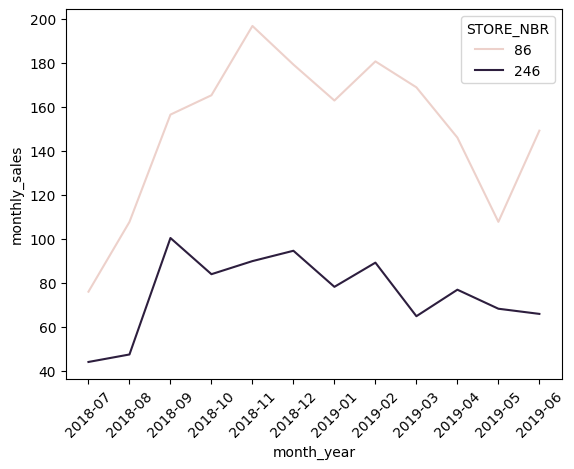

In [151]:
compare = monthly_metrics_df[monthly_metrics_df['STORE_NBR'].isin([86, 246])]

sns.lineplot(data=compare,
             x='month_year',
             y='monthly_sales',
             hue='STORE_NBR')
plt.xticks(rotation=45)
plt.show()

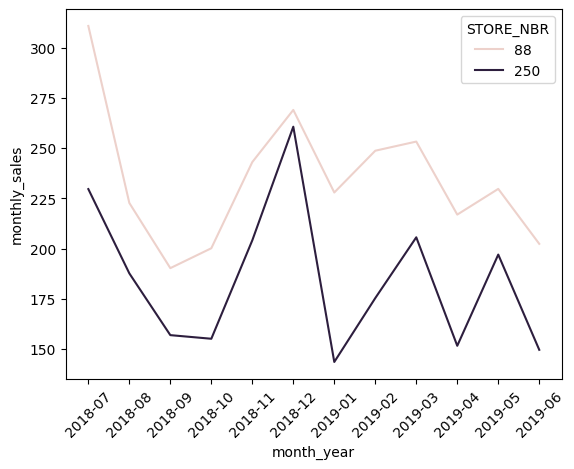

In [156]:
compare = monthly_metrics_df[monthly_metrics_df['STORE_NBR'].isin([88, 250])]

sns.lineplot(data=compare,
             x='month_year',
             y='monthly_sales',
             hue='STORE_NBR')
plt.xticks(rotation=45)
plt.show()

In [159]:
trial_start = '2019-02'
trial_end = '2019-04'

In [160]:
pre_trial = monthly_metrics_df[monthly_metrics_df['month_year'] < trial_start]
trial_period = monthly_metrics_df[
    (monthly_metrics_df['month_year'] >= trial_start) &
    (monthly_metrics_df['month_year'] <= trial_end)
]

In [125]:
trial_store = 77
control_store = 115

trial_sales_pre = pre_trial[pre_trial['STORE_NBR'] == trial_store]['monthly_sales'].sum()
control_sales_pre = pre_trial[pre_trial['STORE_NBR'] == control_store]['monthly_sales'].sum()

scaling_factor = trial_sales_pre / control_sales_pre
scaling_factor


np.float64(0.8653354089414)

In [126]:
trial_sales = trial_period[trial_period['STORE_NBR'] == trial_store][['month_year','monthly_sales']]
control_sales = trial_period[trial_period['STORE_NBR'] == control_store][['month_year','monthly_sales']]

In [127]:
trial_sales = trial_sales.rename(columns={'monthly_sales':'Actual_Sales'})
control_sales = control_sales.rename(columns={'monthly_sales':'Control_Sales'})

In [128]:
comparison = trial_sales.merge(control_sales, on='month_year')

In [129]:
comparison['Expected_Sales'] = comparison['Control_Sales'] * scaling_factor

In [130]:
comparison['Uplift'] = comparison['Actual_Sales'] - comparison['Expected_Sales']

In [131]:
final_table = comparison[['month_year','Actual_Sales','Expected_Sales','Uplift']]
final_table

,month_year,Actual_Sales,Expected_Sales,Uplift
0,2019-02,42.400394,36.863288,5.537105
1,2019-03,42.300394,42.574502,-0.274108
2,2019-04,67.400394,57.631338,9.769056


In [132]:
trial_store = 86
control_store = 246

trial_sales_pre = pre_trial[pre_trial['STORE_NBR'] == trial_store]['monthly_sales'].sum()
control_sales_pre = pre_trial[pre_trial['STORE_NBR'] == control_store]['monthly_sales'].sum()

scaling_factor = trial_sales_pre / control_sales_pre
scaling_factor

np.float64(1.9405908362555457)

In [133]:
trial_sales = trial_period[trial_period['STORE_NBR'] == trial_store][['month_year','monthly_sales']]
control_sales = trial_period[trial_period['STORE_NBR'] == control_store][['month_year','monthly_sales']]

In [134]:
trial_sales = trial_sales.rename(columns={'monthly_sales':'Actual_Sales'})
control_sales = control_sales.rename(columns={'monthly_sales':'Control_Sales'})

In [135]:
comparison = trial_sales.merge(control_sales, on='month_year')
comparison['Expected_Sales'] = comparison['Control_Sales'] * scaling_factor
comparison['Uplift'] = comparison['Actual_Sales'] - comparison['Expected_Sales']
final_table = comparison[['month_year','Actual_Sales','Expected_Sales','Uplift']]
final_table

,month_year,Actual_Sales,Expected_Sales,Uplift
0,2019-02,180.600000,172.907408,7.692592
1,2019-03,168.800000,125.653639,43.146361
2,2019-04,145.950197,149.037376,-3.087179


In [163]:
trial_store = 88
control_store = 250

trial_sales_pre = pre_trial[pre_trial['STORE_NBR'] == trial_store]['monthly_sales'].sum()
control_sales_pre = pre_trial[pre_trial['STORE_NBR'] == control_store]['monthly_sales'].sum()

scaling_factor = trial_sales_pre / control_sales_pre
scaling_factor


np.float64(1.2439535472207863)

In [164]:
trial_sales = trial_period[trial_period['STORE_NBR'] == 88][['month_year','monthly_sales']]
control_sales = trial_period[trial_period['STORE_NBR'] == 250][['month_year','monthly_sales']]
trial_sales = trial_sales.rename(columns={'monthly_sales':'Actual_Sales'})
control_sales = control_sales.rename(columns={'monthly_sales':'Control_Sales'})

In [165]:
comparison = pd.merge(trial_sales,control_sales, on='month_year',how='inner')
comparison['Expected_Sales'] = comparison['Control_Sales'] * scaling_factor
comparison['Uplift'] = comparison['Actual_Sales'] - comparison['Expected_Sales']
final_table = comparison[['month_year','Actual_Sales','Expected_Sales','Uplift']]
final_table

,month_year,Actual_Sales,Expected_Sales,Uplift
0,2019-02,248.700394,218.127499,30.572894
1,2019-03,253.250591,255.756849,-2.506259
2,2019-04,216.900394,188.583358,28.317036
